In [21]:
import pandas as pd


import matplotlib.pyplot as plt  # For plotting
import seaborn as sns      # For advanced visualizations like heatmaps


# Load the CSV file
data = pd.read_csv("https://raw.githubusercontent.com/hamad2343a/tea_vs_coffee_global_report/refs/heads/main/tea_vs_coffee_global_final.csv")

# Check first 5 rows
print(data.head())

# Get basic info about columns
print(data.info())

# Summary statistics
print(data.describe())




      country continent  year  age  gender income_level drink_preference  \
0  Bangladesh      Asia  2015   56    Male          Low           Coffee   
1  Bangladesh      Asia  2015   61   Other         High              Tea   
2  Bangladesh      Asia  2015   59  Female          Low           Coffee   
3  Bangladesh      Asia  2015   41   Other         High           Coffee   
4  Bangladesh      Asia  2015   43   Other       Middle              Tea   

  favorite_drink drink_category  cups_per_day  ... exercise_frequency   bmi  \
0          Mocha         Modern           2.3  ...           Moderate  26.9   
1     Oolong Tea    Traditional           1.3  ...               High  20.9   
2      Americano         Modern           3.2  ...                Low  31.6   
3     Cappuccino         Modern           3.0  ...           Moderate  33.1   
4      Green Tea    Traditional           1.9  ...               High  29.8   

  hydration_level heart_rate  drink_reason  social_setting  time_of_

In [25]:
# Step 3️⃣ – Exploratory Data Analysis (EDA)

# 3a. Categorical Columns
categorical_cols = ['country','continent','gender','income_level','drink_preference',
                    'favorite_drink','drink_category','drink_reason','social_setting',
                    'time_of_day','loyalty_brand','experiment_new_drinks']

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(data[col].value_counts())



Value counts for country:
country
Bangladesh    1000
India         1000
China         1000
Japan         1000
Pakistan      1000
USA           1000
Canada        1000
Brazil        1000
UK            1000
Germany       1000
France        1000
Italy         1000
Spain         1000
Australia     1000
Egypt         1000
Name: count, dtype: int64

Value counts for continent:
continent
Asia       5000
Europe     5000
America    3000
Oceania    1000
Africa     1000
Name: count, dtype: int64

Value counts for gender:
gender
Male      5054
Other     4974
Female    4972
Name: count, dtype: int64

Value counts for income_level:
income_level
Low       6031
Middle    5971
High      2998
Name: count, dtype: int64

Value counts for drink_preference:
drink_preference
Tea       7703
Coffee    7297
Name: count, dtype: int64

Value counts for favorite_drink:
favorite_drink
Mocha          1096
Cappuccino     1049
Espresso       1044
Latte          1040
Flat White     1032
Cold Brew      1023
Americano  

In [26]:
# 3b. Numeric Columns
numeric_cols = ['age','cups_per_day','bmi','hydration_level','heart_rate','satisfaction_level']

print("\nSummary statistics for numeric columns:")
print(data[numeric_cols].describe())



Summary statistics for numeric columns:
                age  cups_per_day           bmi  hydration_level  \
count  15000.000000  15000.000000  15000.000000     15000.000000   
mean      41.115933      2.510380     26.478900         4.990933   
std       13.495386      0.993814      4.914655         2.583608   
min       18.000000      0.000000     18.000000         1.000000   
25%       30.000000      1.800000     22.200000         3.000000   
50%       41.000000      2.500000     26.400000         5.000000   
75%       53.000000      3.200000     30.700000         7.000000   
max       64.000000      6.000000     35.000000         9.000000   

         heart_rate  satisfaction_level  
count  15000.000000        15000.000000  
mean      79.469733            5.028333  
std       11.569253            2.572646  
min       60.000000            1.000000  
25%       69.000000            3.000000  
50%       79.000000            5.000000  
75%       89.000000            7.000000  
max       

In [27]:
# 3c. Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())



Missing values per column:
country                  0
continent                0
year                     0
age                      0
gender                   0
income_level             0
drink_preference         0
favorite_drink           0
drink_category           0
cups_per_day             0
drink_temperature        0
sugar_level              0
milk_usage               0
caffeine_preference      0
taste_score              0
bitterness               0
acidity                  0
aroma_score              0
monthly_spend            0
price_per_cup            0
home_vs_cafe_ratio       0
work_type                0
sleep_hours              0
stress_level             0
exercise_frequency       0
bmi                      0
hydration_level          0
heart_rate               0
drink_reason             0
social_setting           0
time_of_day              0
loyalty_brand            0
experiment_new_drinks    0
satisfaction_level       0
dtype: int64



Correlation Matrix:
                         age  cups_per_day       bmi  hydration_level  \
age                 1.000000     -0.001095 -0.009459         0.007403   
cups_per_day       -0.001095      1.000000 -0.002168         0.006396   
bmi                -0.009459     -0.002168  1.000000         0.006897   
hydration_level     0.007403      0.006396  0.006897         1.000000   
heart_rate          0.014043     -0.006352  0.011964        -0.007722   
satisfaction_level -0.000248     -0.006246  0.003928         0.001473   

                    heart_rate  satisfaction_level  
age                   0.014043           -0.000248  
cups_per_day         -0.006352           -0.006246  
bmi                   0.011964            0.003928  
hydration_level      -0.007722            0.001473  
heart_rate            1.000000            0.000368  
satisfaction_level    0.000368            1.000000  


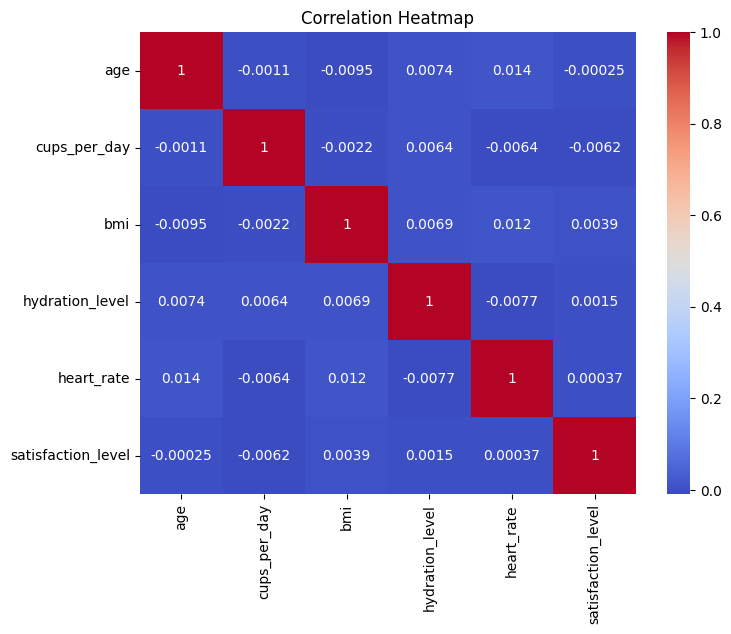

In [28]:
# Step 4️⃣ – Correlations for numeric columns
corr_matrix = data[numeric_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


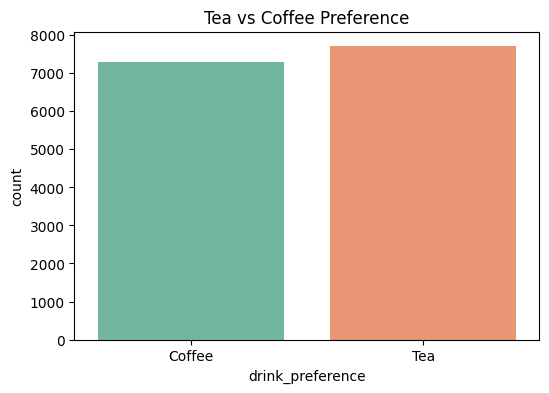

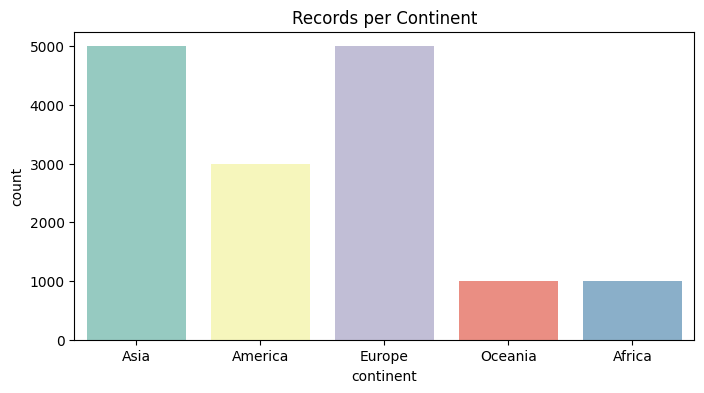

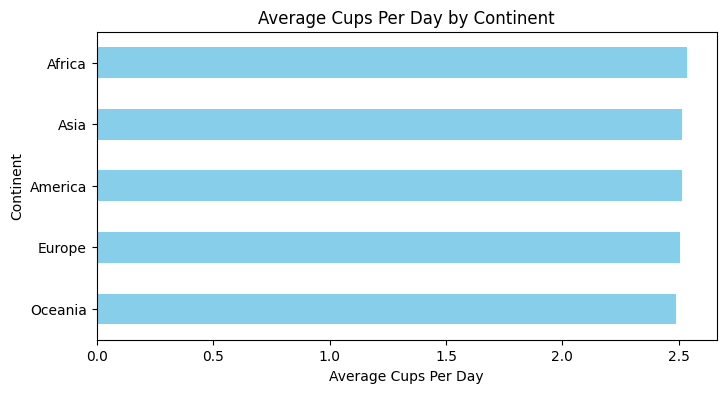

In [56]:
# Visualizations

# Drink Preference Counts
plt.figure(figsize=(6,4))
sns.countplot(
    x='drink_preference',
    data=data,
    hue='drink_preference',  # link palette to hue
    dodge=False,             # keep bars together
    palette='Set2'
)
plt.title("Tea vs Coffee Preference")
plt.show()


#  Records per Continent
plt.figure(figsize=(8,4))
sns.countplot(
    x='continent',
    data=data,
    hue='continent',   # link palette to hue
    dodge=False,       # keep bars together
    palette='Set3'
)
plt.title("Records per Continent")
plt.show()


# Average Cups Per Day by Continent
avg_cups = data.groupby('continent')['cups_per_day'].mean().sort_values()
plt.figure(figsize=(8,4))
avg_cups.plot(kind='barh', color='skyblue')
plt.title("Average Cups Per Day by Continent")
plt.xlabel("Average Cups Per Day")
plt.ylabel("Continent")
plt.show()



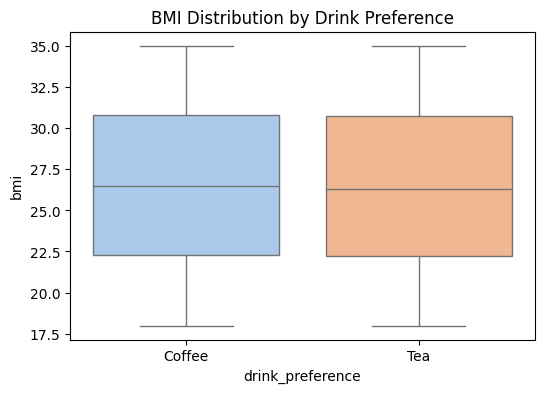

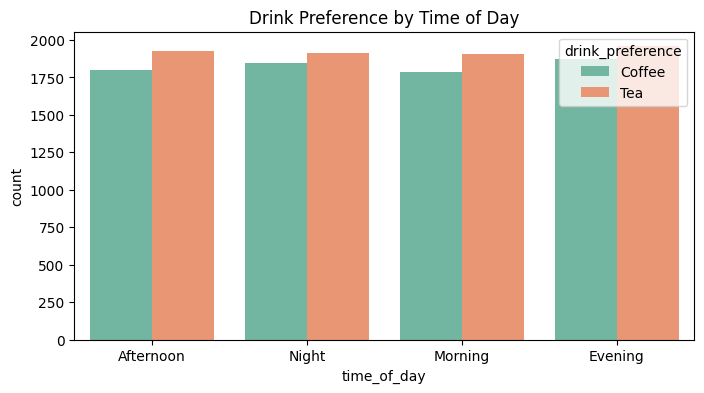

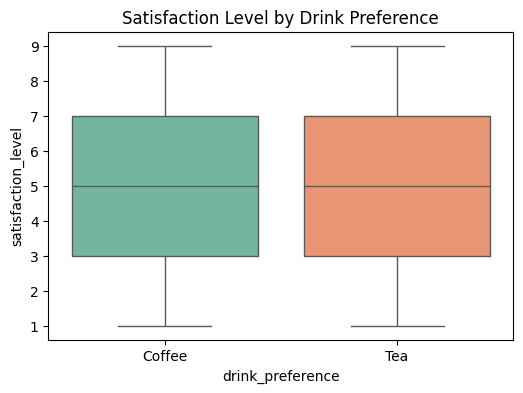

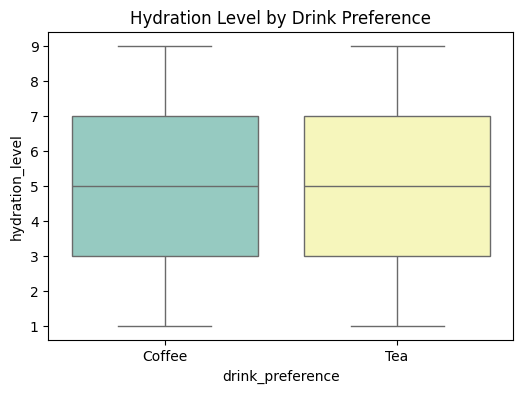

In [48]:
# BMI Distribution by Drink Preference
plt.figure(figsize=(6,4))
sns.boxplot(x='drink_preference', y='bmi', data=data, hue='drink_preference', dodge=False, palette='pastel')
plt.title("BMI Distribution by Drink Preference")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='time_of_day', data=data, hue='drink_preference', palette='Set2')
plt.title("Drink Preference by Time of Day")
plt.show()


# Satisfaction Level by Drink Preference
plt.figure(figsize=(6,4))
sns.boxplot(
    x='drink_preference',
    y='satisfaction_level',
    data=data,
    hue='drink_preference',  # link palette to hue
    dodge=False,             # avoid separating boxes
    palette='Set2'
)
plt.title("Satisfaction Level by Drink Preference")
plt.show()


# Hydration Level by Drink Preference
plt.figure(figsize=(6,4))
sns.boxplot(
    x='drink_preference',
    y='hydration_level',
    data=data,
    hue='drink_preference',  # link the palette
    dodge=False,             # prevent box separation
    palette='Set3'
)
plt.title("Hydration Level by Drink Preference")
plt.show()




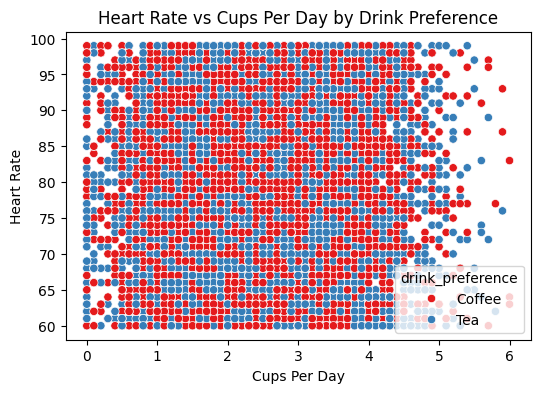

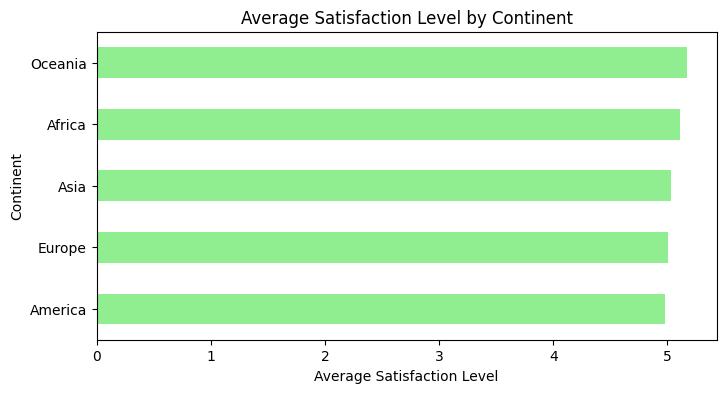

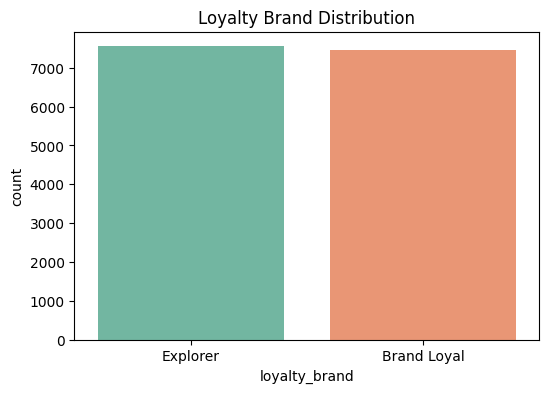

In [51]:
# Heart Rate vs Cups Per Day by Drink Preference
plt.figure(figsize=(6,4))
sns.scatterplot(x='cups_per_day', y='heart_rate', hue='drink_preference', data=data, palette='Set1')
plt.title("Heart Rate vs Cups Per Day by Drink Preference")
plt.xlabel("Cups Per Day")
plt.ylabel("Heart Rate")
plt.show()

# 5h. Average Satisfaction Level by Continent
avg_satisfaction = data.groupby('continent')['satisfaction_level'].mean().sort_values()
plt.figure(figsize=(8,4))
avg_satisfaction.plot(kind='barh', color='lightgreen')
plt.title("Average Satisfaction Level by Continent")
plt.xlabel("Average Satisfaction Level")
plt.ylabel("Continent")
plt.show()

# 5i. Loyalty Brand Counts
plt.figure(figsize=(6,4))
sns.countplot(
    x='loyalty_brand',
    data=data,
    hue='loyalty_brand',  # link palette to hue
    dodge=False,          # keep bars together
    palette='Set2'
)
plt.title("Loyalty Brand Distribution")
plt.show()



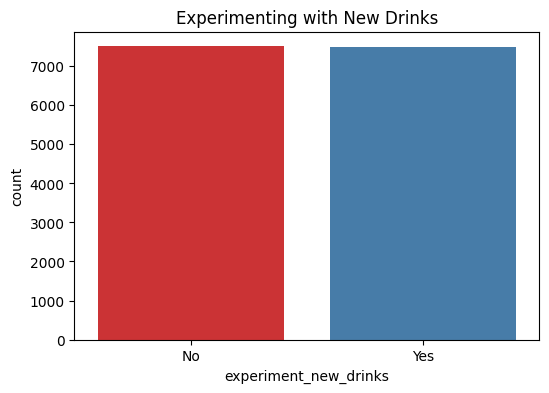

In [54]:
# 5j. Experimenting with New Drinks
plt.figure(figsize=(6,4))
sns.countplot(
    x='experiment_new_drinks',
    data=data,
    hue='experiment_new_drinks',  # link palette to hue
    dodge=False,                  # keep bars together
    palette='Set1'
)
plt.title("Experimenting with New Drinks")
plt.show()


# Step 6️⃣ – Save Cleaned Dataset (Optional)
data.to_csv("tea_vs_coffee_global_cleaned_full.csv", index=False)

